# Phase 3 — Modèles Machine Learning

Importation et chargement du dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df_features = pd.read_csv(r"C:/Users/21624/Desktop/dataset pfe/df_features_ready.csv")
df_features['timestamp'] = pd.to_datetime(df_features['timestamp'])

# Vérification des serveurs disponibles
serveurs = sorted(df_features['serveur_id'].unique())
print(f"Dataset chargé : {df_features.shape[0]} lignes, {df_features.shape[1]} colonnes")
print(f"Serveurs disponibles ({len(serveurs)}) : {serveurs}")
print()

# Vérification taille par serveur
for srv in serveurs:
    n = len(df_features[df_features['serveur_id'] == srv])
    print(f"  Serveur {srv} : {n} observations")


Dataset chargé : 20105 lignes, 20 colonnes
Serveurs disponibles (5) : ['24ae8d', '53ea38', '5f5533', '77c1ca', '825cc2']

  Serveur 24ae8d : 4021 observations
  Serveur 53ea38 : 4021 observations
  Serveur 5f5533 : 4021 observations
  Serveur 77c1ca : 4021 observations
  Serveur 825cc2 : 4021 observations


chargement et vérification des features

In [5]:
FEATURES_ML = ['lag_1','lag_2','lag_3','lag_5','lag_10','moyenne_mobile_5','rolling_mean_10','rolling_std_5',
               'rolling_std_10','diff_1','diff_2','hour','weekday']

features_absentes = [f for f in FEATURES_ML if f not in df_features.columns]
if features_absentes:
    print(f'[AVERTISSEMENT] Features absentes : {features_absentes}')
else:
    print(f'13 features ML disponibles : {FEATURES_ML}')


13 features ML disponibles : ['lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_10', 'moyenne_mobile_5', 'rolling_mean_10', 'rolling_std_5', 'rolling_std_10', 'diff_1', 'diff_2', 'hour', 'weekday']


## Validation temporelle — TimeSeriesSplit par serveur

On applique le `TimeSeriesSplit` **séparément sur chaque serveur** pour respecter l'ordre chronologique de chaque série.

In [6]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

# Démonstration sur le premier serveur
srv_demo = sorted(df_features['serveur_id'].unique())[0]
df_demo  = df_features[df_features['serveur_id'] == srv_demo].copy()
X_demo   = df_demo[FEATURES_ML]

print(f"Démonstration TimeSeriesSplit — Serveur {srv_demo}")
print(f"Taille totale : {len(X_demo)} observations")
print()

for i, (train_idx, test_idx) in enumerate(tscv.split(X_demo)):
    print(f"  Split {i+1} | Train: {len(train_idx):5d} | Test: {len(test_idx):5d} | "
          f"Train → {train_idx[0]}:{train_idx[-1]} | Test → {test_idx[0]}:{test_idx[-1]}")


Démonstration TimeSeriesSplit — Serveur 24ae8d
Taille totale : 4021 observations

  Split 1 | Train:   671 | Test:   670 | Train → 0:670 | Test → 671:1340
  Split 2 | Train:  1341 | Test:   670 | Train → 0:1340 | Test → 1341:2010
  Split 3 | Train:  2011 | Test:   670 | Train → 0:2010 | Test → 2011:2680
  Split 4 | Train:  2681 | Test:   670 | Train → 0:2680 | Test → 2681:3350
  Split 5 | Train:  3351 | Test:   670 | Train → 0:3350 | Test → 3351:4020


Visualisation des splits

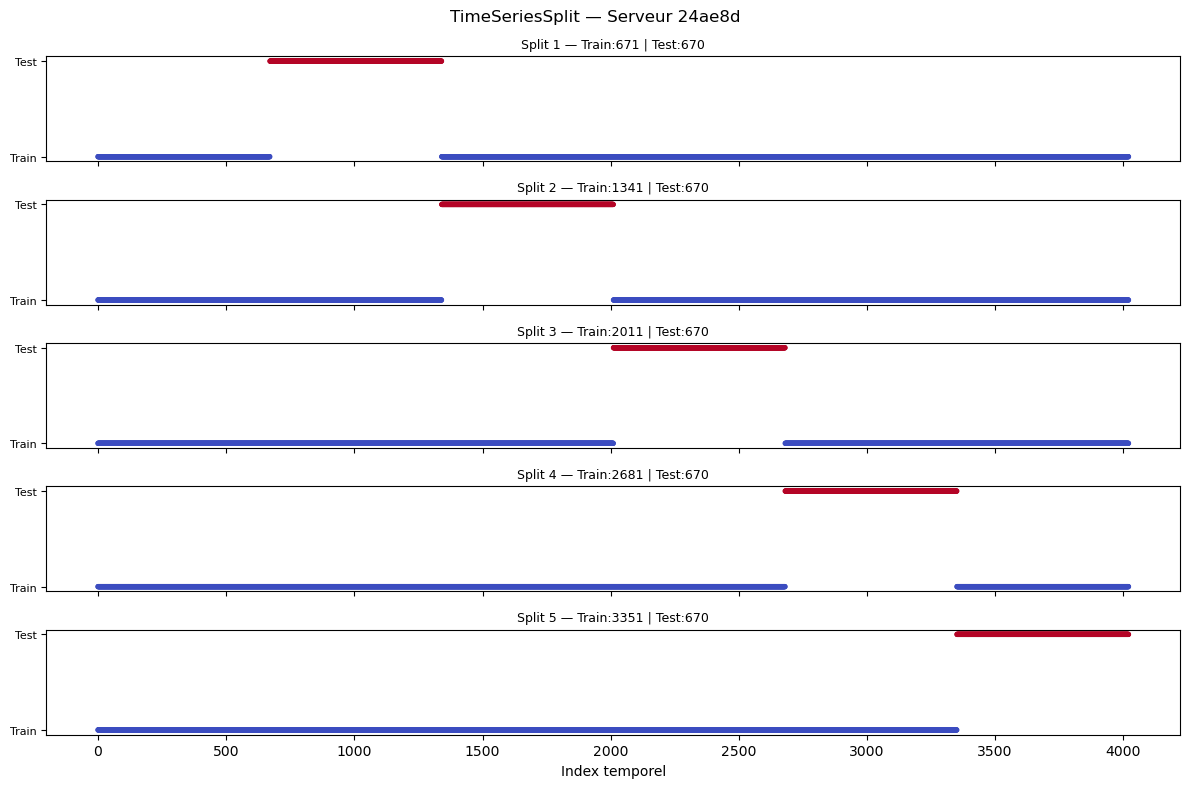

In [7]:
# Visualisation des splits sur le serveur de démonstration
fig, axes = plt.subplots(5, 1, figsize=(12, 8), sharex=True)

for i, (train_idx, test_idx) in enumerate(tscv.split(X_demo)):
    split_visual = np.zeros(len(X_demo))
    split_visual[train_idx] = 0
    split_visual[test_idx]  = 1
    axes[i].scatter(range(len(X_demo)), split_visual,
                    c=split_visual, cmap='coolwarm', s=8)
    axes[i].set_yticks([0, 1])
    axes[i].set_yticklabels(['Train', 'Test'], fontsize=8)
    axes[i].set_title(f'Split {i+1} — Train:{len(train_idx)} | Test:{len(test_idx)}',
                      fontsize=9)

axes[-1].set_xlabel('Index temporel')
plt.suptitle(f'TimeSeriesSplit — Serveur {srv_demo}', fontsize=12)
plt.tight_layout()
plt.show()


Partie A: prédiction des valeurs CPU

Importation des bibliothéques et définition des models

**Choix des modèles de Machine Learning**

Trois modèles ont été sélectionnés :
- Random Forest
- XGBoost
- LightGBM

**Justification**

- Adaptés aux données tabulaires
- Capables de modéliser des relations non linéaires
- Robustes au bruit
- Permettent d’extraire l’importance des variables

     Random Forest → Bagging  
     XGBoost / LightGBM → Boosting

Ces modèles offrent un bon compromis entre performance et interprétabilité.

In [8]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

MODELS = {
    'RandomForest': RandomForestRegressor(
        n_estimators=100, max_depth=6,
        random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBRegressor(
        n_estimators=100, learning_rate=0.1,
        max_depth=4, random_state=42, verbosity=0
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=100, learning_rate=0.1,
        max_depth=4, random_state=42, verbose=-1
    ),
}

print('3 modèles définis :')
for nom in MODELS:
    print(f'  - {nom}')


3 modèles définis :
  - RandomForest
  - XGBoost
  - LightGBM


**Génération des combinaisons de features**

`itertools.combinations` génère toutes les combinaisons possibles de 1 à 13 features .  
Pour chaque combinaison × chaque modèle × chaque serveur, on calcule MAE, RMSE et R².

In [9]:
from itertools import combinations

all_features       = FEATURES_ML
features_presentes = [f for f in all_features if f in df_features.columns]
features_absentes  = [f for f in all_features if f not in df_features.columns]

if features_absentes:
    print(f'[AVERTISSEMENT] Features absentes : {features_absentes}')
else:
    print(f'{len(features_presentes)} features disponibles : {features_presentes}')

feature_sets = []
for i in range(1, len(features_presentes) + 1):
    for combo in combinations(features_presentes, i):
        feature_sets.append(list(combo))

print(f'Nombre total de combinaisons : {len(feature_sets)}')


13 features disponibles : ['lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_10', 'moyenne_mobile_5', 'rolling_mean_10', 'rolling_std_5', 'rolling_std_10', 'diff_1', 'diff_2', 'hour', 'weekday']
Nombre total de combinaisons : 8191


## Boucle d'expérimentation

**Approche serveur par serveur**

Chaque serveur a son propre comportement temporel. Mélanger 5 serveurs dans un seul entraînement sans alignement temporel produit des métriques aberrantes (MAE = 34, R² = -8).  
En traitant chaque serveur séparément, on garantit que le split train/test est chronologiquement cohérent.

**Logique :**  
```
pour chaque serveur:
    pour chaque combinaison de features (100):
        pour chaque modèle (3):
            TimeSeriesSplit(5) → MAE, RMSE, R²
```

Les métriques sont moyennées par (modèle, combinaison) sur tous les serveurs.

**Points clés:**
- clone(model) :à chaque split → pas de contamination entre splits
- Split **par serveur** → alignement temporel garanti
- Métriques moyennées sur les 5 splits **et** sur les 5 serveurs
- Optimisation du temps de calcul:Un échantillonnage aléatoire de 100 combinaisons est utilisé pour réduire le temps d’entraînement tout en conservant une diversité de tests.

In [ ]:
import random
serveurs   = sorted(df_features['serveur_id'].unique())
random.seed(42)
feature_sets = random.sample(feature_sets, 100)   # LIMITATION À 100 COMBINAISONS
results    = []
total      = len(feature_sets) * len(MODELS)
compteur   = 0

print(f"Lancement : {len(feature_sets)} combos × {len(MODELS)} modèles × {len(serveurs)} serveurs")
print(f"Total expériences par serveur : {total}")
print()

for features in feature_sets:
    for model_name, model in MODELS.items():
        compteur += 1
        mae_all  = []
        rmse_all = []
        r2_all   = []

        for srv in serveurs:
            # ── Isoler les données de CE serveur, triées par temps 
            df_srv = df_features[df_features['serveur_id'] == srv].sort_values('timestamp').reset_index(drop=True)
            X_srv  = df_srv[features]
            y_srv  = df_srv['target']

            # ── TimeSeriesSplit sur CE serveur 
            for train_idx, test_idx in tscv.split(X_srv):
                X_train = X_srv.iloc[train_idx]
                X_test  = X_srv.iloc[test_idx]
                y_train = y_srv.iloc[train_idx]
                y_test  = y_srv.iloc[test_idx]

                # Clone propre à chaque split
                m = clone(model)
                m.fit(X_train, y_train)
                y_pred = m.predict(X_test)

                mae_all.append(mean_absolute_error(y_test, y_pred))
                rmse_all.append(np.sqrt(mean_squared_error(y_test, y_pred)))
                r2_all.append(r2_score(y_test, y_pred))

        # Moyenne sur tous les splits de tous les serveurs
        results.append({
            'Model'   : model_name,
            'Features': ', '.join(features),
            'Nb_feat' : len(features),
            'MAE'     : round(np.mean(mae_all),  5),
            'RMSE'    : round(np.mean(rmse_all), 5),
            'R2'      : round(np.mean(r2_all),   4),
        })

        if compteur % 50 == 0 or compteur == total:
            print(f'  [{compteur}/{total}] terminés...')

results_df = pd.DataFrame(results)
print(f'\nExpérimentation terminée — {len(results_df)} expériences.')


Lancement : 100 combos × 3 modèles × 5 serveurs
Total expériences par serveur : 300



  [50/300] terminés...
  [100/300] terminés...
  [150/300] terminés...
  [200/300] terminés...
  [250/300] terminés...
  [300/300] terminés...

Expérimentation terminée — 300 expériences.


**Affichage du résultats :Top 15**

In [11]:
results_df_sorted = results_df.sort_values('MAE').reset_index(drop=True)
results_df_sorted.index += 1

print('=== TOP 15 — triés par MAE ===')
print(results_df_sorted[['Model', 'Features', 'Nb_feat', 'MAE', 'RMSE', 'R2']]
      .head(15).to_string())

best = results_df_sorted.iloc[0]
print(f'\n>>> MEILLEUR : {best["Model"]} | {best["Features"]}')
print(f'    MAE={best["MAE"]}  RMSE={best["RMSE"]}  R²={best["R2"]}')


=== TOP 15 — triés par MAE ===
           Model                                                                                        Features  Nb_feat      MAE     RMSE      R2
1        XGBoost                                                     lag_1, lag_2, rolling_std_5, diff_1, diff_2        5  0.04403  0.08903  0.6075
2        XGBoost                            lag_1, lag_3, lag_5, lag_10, moyenne_mobile_5, rolling_std_5, diff_1        7  0.04437  0.08911  0.6124
3       LightGBM                            lag_1, lag_3, lag_5, lag_10, moyenne_mobile_5, rolling_std_5, diff_1        7  0.04452  0.08793  0.6093
4       LightGBM                                                     lag_1, lag_2, rolling_std_5, diff_1, diff_2        5  0.04460  0.08855  0.5824
5   RandomForest                            lag_1, lag_3, lag_5, lag_10, moyenne_mobile_5, rolling_std_5, diff_1        7  0.04476  0.08833  0.5757
6       LightGBM                          lag_1, moyenne_mobile_5, rolling_std_5,

**Résultats des expérimentations**
Les performances des modèles sont regroupées dans un tableau afin de faciliter la comparaison.

**Sélection des meilleures combinaisons**
Les résultats sont triés selon le MAE afin d’identifier les modèles les plus performants.

``le modéle vainqueur est XGBoost avec la combinaison lag_1,lag_2,rolling_std_5,diff_1 et diff_2``

**heatmap MAE** : Modele* nombre de feature

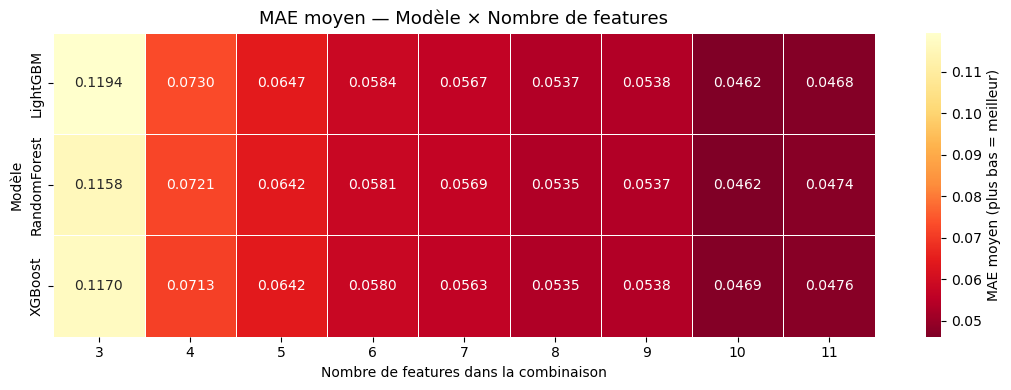

In [12]:
pivot_nb = results_df.groupby(['Model', 'Nb_feat'])['MAE'].mean().unstack()

plt.figure(figsize=(11, 4))
sns.heatmap(
    pivot_nb,
    annot=True,
    fmt='.4f',
    cmap='YlOrRd_r',
    linewidths=0.5,
    cbar_kws={'label': 'MAE moyen (plus bas = meilleur)'}
)
plt.title('MAE moyen — Modèle × Nombre de features', fontsize=13)
plt.xlabel('Nombre de features dans la combinaison')
plt.ylabel('Modèle')
plt.tight_layout()
plt.savefig('heatmap_mae_nb_features.png', dpi=150, bbox_inches='tight')
plt.show()

La heatmap permet de voir d'un coup d'œil quel modèle × quelle combinaison donne les meilleurs résultats.  
**Plus la couleur est foncée = meilleur MAE (plus bas).**

**Visualisation des top 10**

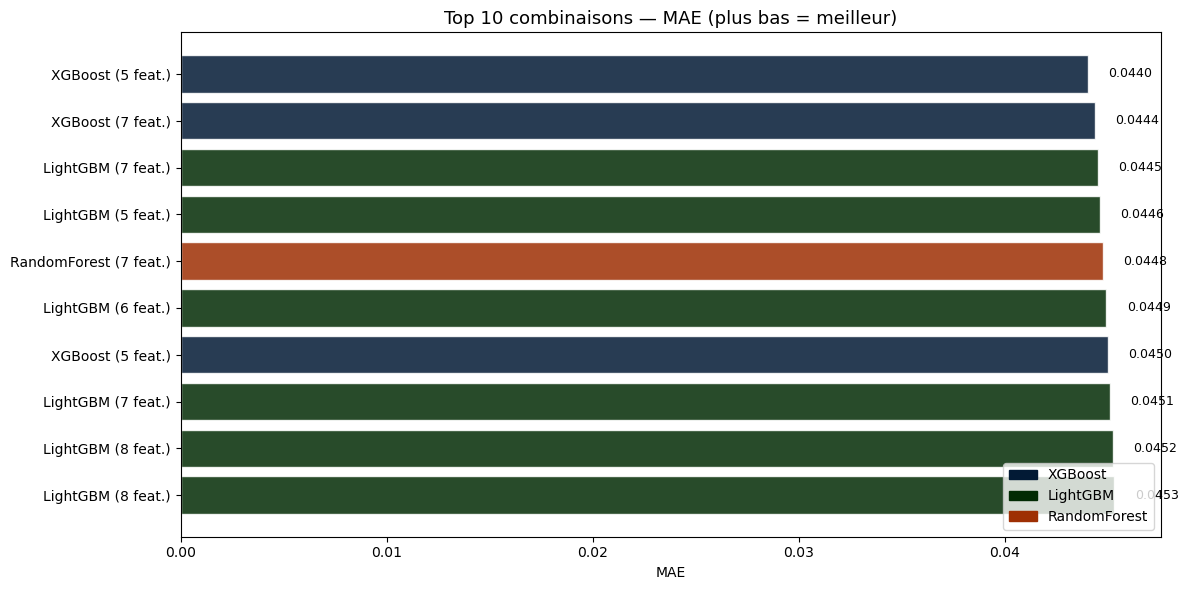

Sauvegardé : top10_mae.png


In [13]:
from matplotlib import patches


top10 = results_df_sorted.head(10).copy()
couleurs_modele = {
    'XGBoost'      : "#021A35",
    'LightGBM'     : "#022B04",
    'RandomForest': "#9E2F03",
}
couleurs = [couleurs_modele[m] for m in top10['Model']]
labels   = [f"{r['Model']} ({r['Nb_feat']} feat.)" for _, r in top10.iterrows()]

plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(top10)), top10['MAE'],
                color=couleurs, alpha=0.85, edgecolor='white', linewidth=1)
plt.yticks(range(len(top10)), labels)
plt.gca().invert_yaxis()

for bar, val in zip(bars, top10['MAE']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

legend_handles = [patches.Patch(color=c, label=m)
                  for m, c in couleurs_modele.items()]
plt.legend(handles=legend_handles, loc='lower right')
plt.title('Top 10 combinaisons — MAE (plus bas = meilleur)', fontsize=13)
plt.xlabel('MAE')
plt.tight_layout()
plt.savefig('top10_mae.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : top10_mae.png')

**comparaison des métriques par modèle**:
On compare les 3 modèles sur leur meilleure combinaison respective.


=== Meilleure combinaison par modèle ===
       Model                                                             Features     MAE    RMSE     R2
    LightGBM lag_1, lag_3, lag_5, lag_10, moyenne_mobile_5, rolling_std_5, diff_1 0.04452 0.08793 0.6093
RandomForest lag_1, lag_3, lag_5, lag_10, moyenne_mobile_5, rolling_std_5, diff_1 0.04476 0.08833 0.5757
     XGBoost                          lag_1, lag_2, rolling_std_5, diff_1, diff_2 0.04403 0.08903 0.6075


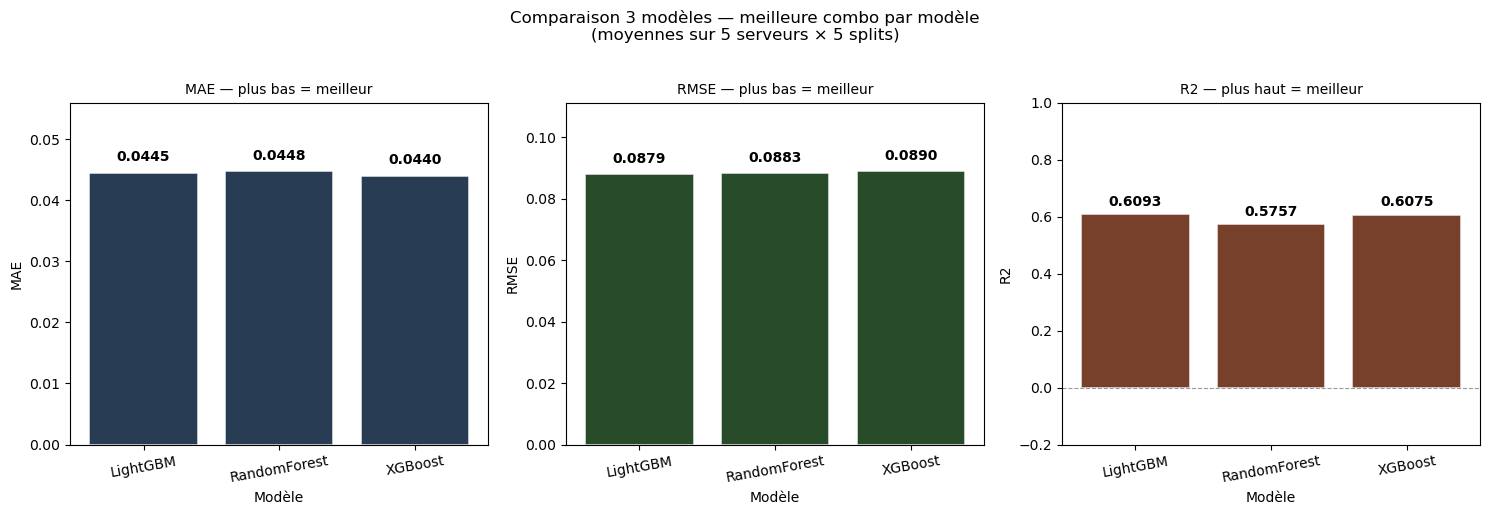

Sauvegardé : comparaison_3modeles.png


In [14]:
meilleur_par_modele = results_df.loc[
    results_df.groupby('Model')['MAE'].idxmin()
].reset_index(drop=True)

print('=== Meilleure combinaison par modèle ===')
print(meilleur_par_modele[['Model','Features','MAE','RMSE','R2']].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
configs = [
    ('MAE',  'MAE — plus bas = meilleur',  '#021A35'),
    ('RMSE', 'RMSE — plus bas = meilleur', '#022B04'),
    ('R2',   'R2 — plus haut = meilleur',  '#5F1E04'),
]

for ax, (metrique, titre, couleur) in zip(axes, configs):
    valeurs = meilleur_par_modele[metrique]
    bars = ax.bar(
        meilleur_par_modele['Model'], valeurs,
        color=couleur, alpha=0.85, edgecolor='white', linewidth=1.2
    )
    for bar, val in zip(bars, valeurs):
        ypos = val + abs(val) * 0.03 if val >= 0 else val - abs(val) * 0.08
        ax.text(bar.get_x() + bar.get_width() / 2, ypos,
                f'{val:.4f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    ax.set_title(titre, fontsize=10)
    ax.set_xlabel('Modèle')
    ax.set_ylabel(metrique)
    ax.tick_params(axis='x', rotation=10)
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    vmin, vmax = valeurs.min(), valeurs.max()
    marge = abs(vmax - vmin) * 0.25 if abs(vmax - vmin) > 0 else 0.1
    if metrique == 'R2':
        ax.set_ylim(min(vmin - marge, -0.2), max(vmax + marge, 1.0))
    else:
        ax.set_ylim(0, vmax * 1.25)

plt.suptitle('Comparaison 3 modèles — meilleure combo par modèle\n(moyennes sur 5 serveurs × 5 splits)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('comparaison_3modeles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : comparaison_3modeles.png')


## Entraînement final 
**3 modèles × meilleure combo × chaque serveur**

``Protocole identique à la CV`` : 5 splits TimeSeriesSplit × 5 serveurs.
Cela garantit que MAE_test et R²_test sont directement comparables à MAE_cv et R²_cv.

La courbe visuelle utilise le **dernier split** (le plus représentatif) et les valeurs réelles (`expm1`).

── RandomForest ──
   Meilleure combo      : ['lag_1', 'lag_3', 'lag_5', 'lag_10', 'moyenne_mobile_5', 'rolling_std_5', 'diff_1']
   MAE_cv  = 0.04476  |  R2_cv  = 0.5757
   MAE_test = 0.04476  |  R2_test = 0.5757
   Ecart MAE : 0.0%  |  Ecart R² : 0.0000
   Statut : OK



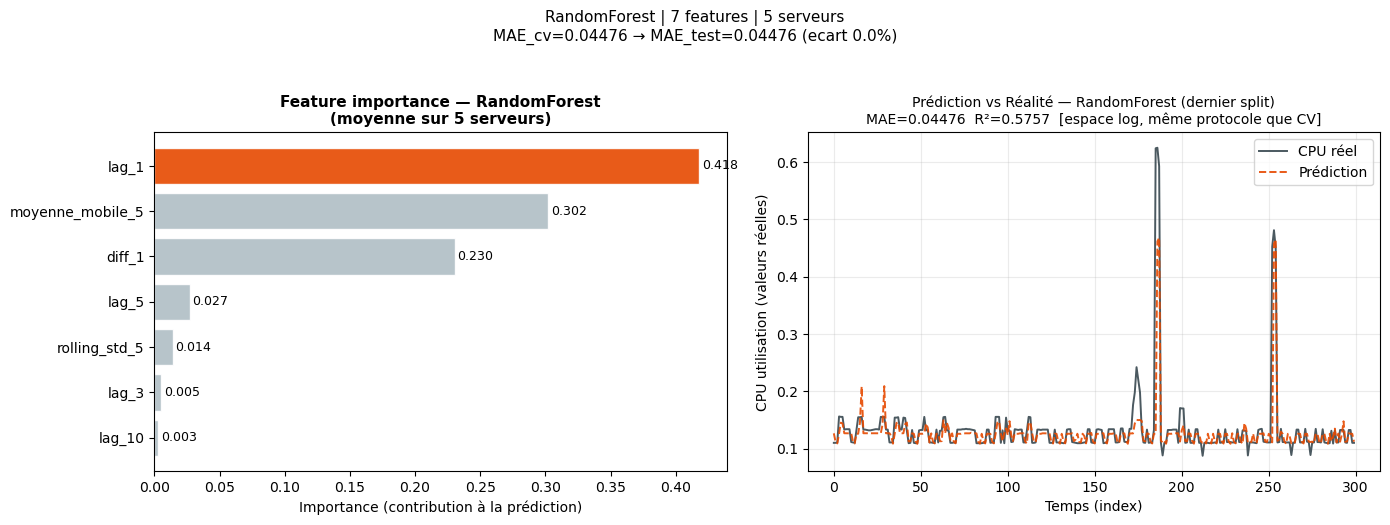

Sauvegardé : final_randomforest.png

── XGBoost ──
   Meilleure combo      : ['lag_1', 'lag_2', 'rolling_std_5', 'diff_1', 'diff_2']
   MAE_cv  = 0.04403  |  R2_cv  = 0.6075
   MAE_test = 0.04403  |  R2_test = 0.6075
   Ecart MAE : 0.0%  |  Ecart R² : 0.0000
   Statut : OK



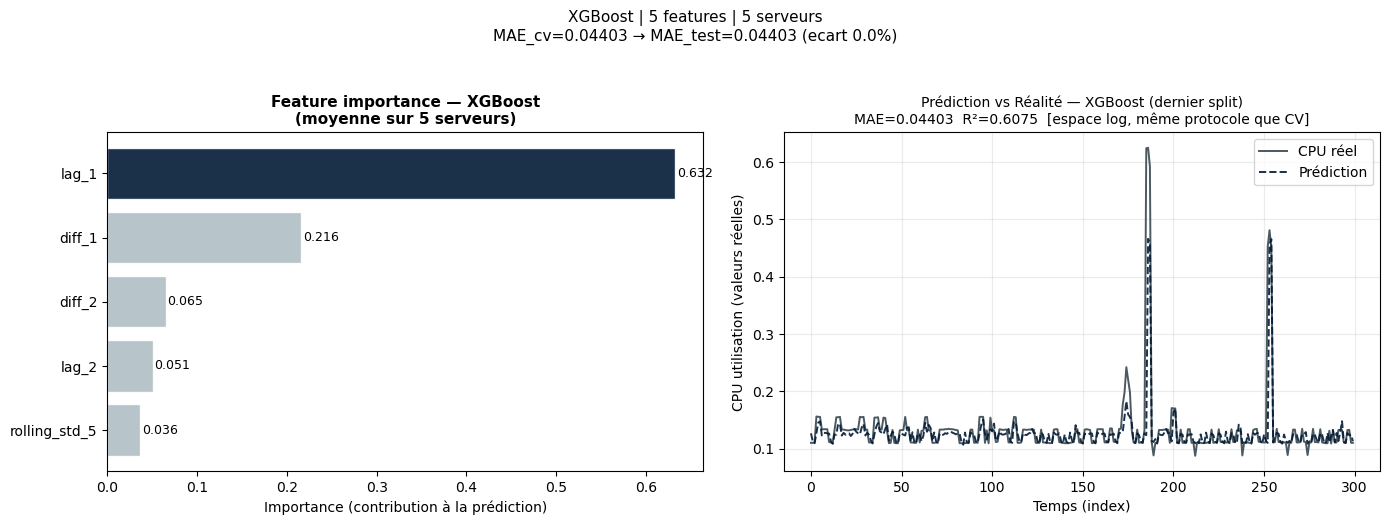

Sauvegardé : final_xgboost.png

── LightGBM ──
   Meilleure combo      : ['lag_1', 'lag_3', 'lag_5', 'lag_10', 'moyenne_mobile_5', 'rolling_std_5', 'diff_1']
   MAE_cv  = 0.04452  |  R2_cv  = 0.6093
   MAE_test = 0.04452  |  R2_test = 0.6093
   Ecart MAE : 0.0%  |  Ecart R² : 0.0000
   Statut : OK



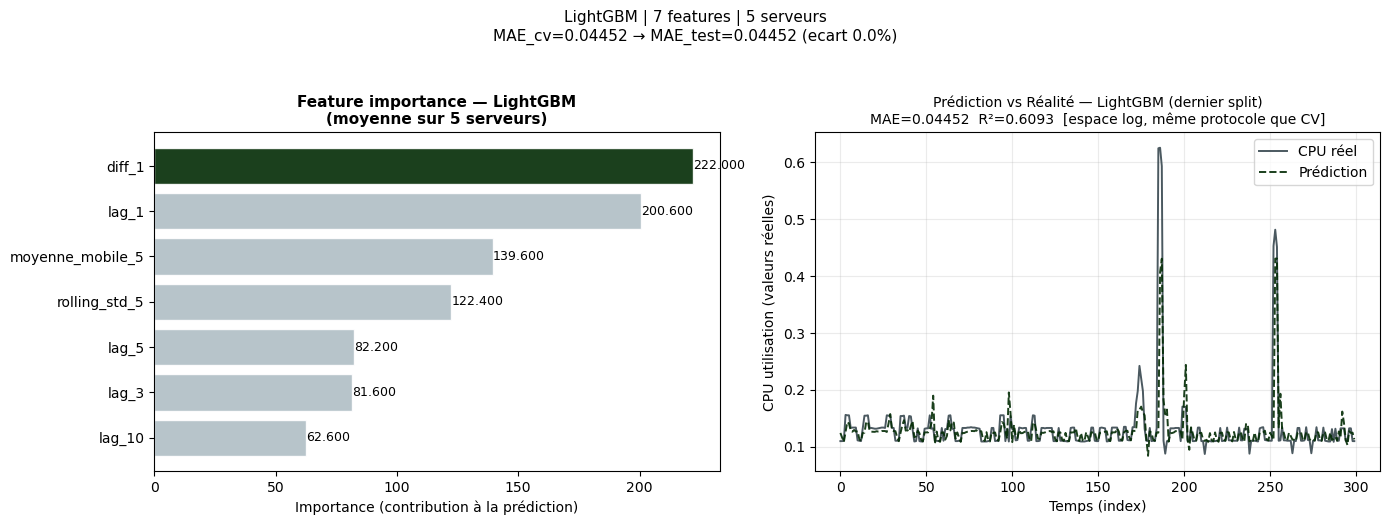

Sauvegardé : final_lightgbm.png



In [15]:
import matplotlib.gridspec as gridspec
serveurs         = sorted(df_features['serveur_id'].unique())
resultats_finaux = []

couleurs_modele = {
    'RandomForest': "#E64900",
    'XGBoost'     : '#021A35',
    'LightGBM'    : '#022B04',
}
N_SPLITS = 5

for model_name, model in MODELS.items():
    best_row      = results_df[results_df['Model'] == model_name].sort_values('MAE').iloc[0]
    best_features = best_row['Features'].split(', ')

    # Vérification que toutes les features sont valides
    features_invalides = [f for f in best_features if f not in FEATURES_ML]
    if features_invalides:
        print(f'[ERREUR] {model_name} : features invalides : {features_invalides}')
        continue

    print(f'── {model_name} ──')
    print(f'   Meilleure combo      : {best_features}')
    print(f'   MAE_cv  = {best_row["MAE"]:.5f}  |  R2_cv  = {best_row["R2"]:.4f}')

    # ── Évaluation sur TOUS les splits
    mae_all_splits  = []
    rmse_all_splits = []
    r2_all_splits   = []

    # ── Évaluation du dernier split
    y_test_last = []
    y_pred_last = []
    y_test_reel_last = []
    y_pred_reel_last = []
    importances_cumul = np.zeros(len(best_features))

    for srv in serveurs:
        df_srv = df_features[df_features['serveur_id'] == srv].sort_values('timestamp').reset_index(drop=True)
        X_srv = df_srv[best_features]
        y_srv = df_srv['target']

        tscv_eval = TimeSeriesSplit(n_splits=N_SPLITS)
        splits_list = list(tscv_eval.split(X_srv))

        for split_i, (train_idx, test_idx) in enumerate(splits_list):
            X_tr = X_srv.iloc[train_idx]
            X_te = X_srv.iloc[test_idx]
            y_tr = y_srv.iloc[train_idx]
            y_te = y_srv.iloc[test_idx]

            m = clone(model)
            m.fit(X_tr, y_tr)
            y_pr = m.predict(X_te)

            # Métriques sur tous les splits 
            mae_all_splits.append(mean_absolute_error(y_te, y_pr))
            rmse_all_splits.append(np.sqrt(mean_squared_error(y_te, y_pr)))
            r2_all_splits.append(r2_score(y_te, y_pr))

            # Dernier split uniquement → courbe visuelle + feature importance
            if split_i == N_SPLITS - 1:
                y_test_last.extend(y_te.values)
                y_pred_last.extend(y_pr)
                y_test_reel_last.extend(np.expm1(y_te.values))
                y_pred_reel_last.extend(np.expm1(y_pr))
                importances_cumul += m.feature_importances_

    # ── Métriques finales — même protocole que la CV 
    mae_f  = np.mean(mae_all_splits)
    rmse_f = np.mean(rmse_all_splits)
    r2_f   = np.mean(r2_all_splits)

    print(f'   MAE_test = {mae_f:.5f}  |  R2_test = {r2_f:.4f}')
    ecart_mae = abs(mae_f - best_row['MAE']) / best_row['MAE'] * 100
    ecart_r2  = abs(r2_f  - best_row['R2'])
    print(f'   Ecart MAE : {ecart_mae:.1f}%  |  Ecart R² : {ecart_r2:.4f}')
    statut = 'OK' if ecart_mae < 10 else ('Acceptable' if ecart_mae < 20 else 'A verifier')
    print(f'   Statut : {statut}')
    print()

    resultats_finaux.append({
        'Modele'      : model_name,
        'Best_combo'  : ', '.join(best_features),
        'Nb_features' : len(best_features),
        'MAE_cv'      : round(best_row['MAE'], 5),
        'R2_cv'       : round(best_row['R2'],  4),
        'MAE_test'    : round(mae_f,  5),
        'RMSE_test'   : round(rmse_f, 5),
        'R2_test'     : round(r2_f,   4),
        'Ecart_MAE_pct': round(ecart_mae, 1),
    })
    # Feature importance moyenne (sur les derniers splits de chaque serveur)
    importances_moy = importances_cumul / len(serveurs)
    df_imp = pd.DataFrame({
        'Feature'    : best_features,
        'Importance' : importances_moy
    }).sort_values('Importance', ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Graphique 1 — feature importance
    idx_max      = df_imp['Importance'].idxmax()
    couleurs_imp = [couleurs_modele[model_name] if i == idx_max
                    else '#B0BEC5' for i in df_imp.index]
    bars = axes[0].barh(df_imp['Feature'], df_imp['Importance'],
                        color=couleurs_imp, alpha=0.9, edgecolor='white')
    for bar, val in zip(bars, df_imp['Importance']):
        axes[0].text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                     f'{val:.3f}', va='center', fontsize=9)
    axes[0].set_title(
        f'Feature importance — {model_name}\n(moyenne sur {len(serveurs)} serveurs)',
        fontsize=11, fontweight='bold'
    )
    axes[0].set_xlabel('Importance (contribution à la prédiction)')

    # Graphique 2 — prédiction vs réalité (dernier split, valeurs réelles)
    y_tp = np.array(y_test_reel_last)
    y_pp = np.array(y_pred_reel_last)
    n = min(300, len(y_tp))
    axes[1].plot(y_tp[:n], label='CPU réel',color='#37474F', linewidth=1.4, alpha=0.9)
    axes[1].plot(y_pp[:n], label='Prédiction',color=couleurs_modele[model_name],
                 linewidth=1.4, linestyle='--', alpha=0.9)
    axes[1].set_title(
        f'Prédiction vs Réalité — {model_name} (dernier split)\n'
        f'MAE={mae_f:.5f}  R²={r2_f:.4f}  [espace log, même protocole que CV]',
        fontsize=10
    )
    axes[1].set_xlabel('Temps (index)')
    axes[1].set_ylabel('CPU utilisation (valeurs réelles)')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.25)

    plt.suptitle(
        f'{model_name} | {len(best_features)} features | {len(serveurs)} serveurs\n'
        f'MAE_cv={best_row["MAE"]:.5f} → MAE_test={mae_f:.5f} (ecart {ecart_mae:.1f}%)',
        fontsize=11, y=1.04
    )
    plt.tight_layout()
    fname = f'final_{model_name.lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Sauvegardé : {fname}')
    print()



**Importance des variables**
Cette étape permet d’identifier les variables les plus influentes dans la prédiction pour chaque modèle 

## Tableau comparatif final — CV vs Test

Métriques calculées avec **le même protocole** (5 splits × 5 serveurs, espace log).
Un faible écart entre MAE_cv et MAE_test valide la robustesse du modèle.

   COMPARAISON FINALE — 3 MODÈLES | MÊME PROTOCOLE QUE LA CV
      Modele  Nb_features  MAE_cv  MAE_test  R2_cv  R2_test  RMSE_test  Ecart_MAE_pct
RandomForest            7 0.04476   0.04476 0.5757   0.5757    0.08833            0.0
     XGBoost            5 0.04403   0.04403 0.6075   0.6075    0.08903            0.0
    LightGBM            7 0.04452   0.04452 0.6093   0.6093    0.08793            0.0

Cohérence CV / test (MAE) :
  RandomForest    : ecart MAE = 0.0%  [Excellent]
  XGBoost         : ecart MAE = 0.0%  [Excellent]
  LightGBM        : ecart MAE = 0.0%  [Excellent]

Cohérence CV / test (R²) :
  RandomForest    : ecart R² = 0.0000  [Excellent]
  XGBoost         : ecart R² = 0.0000  [Excellent]
  LightGBM        : ecart R² = 0.0000  [Excellent]

>>> VAINQUEUR FINAL : XGBoost  (MAE test le plus bas)


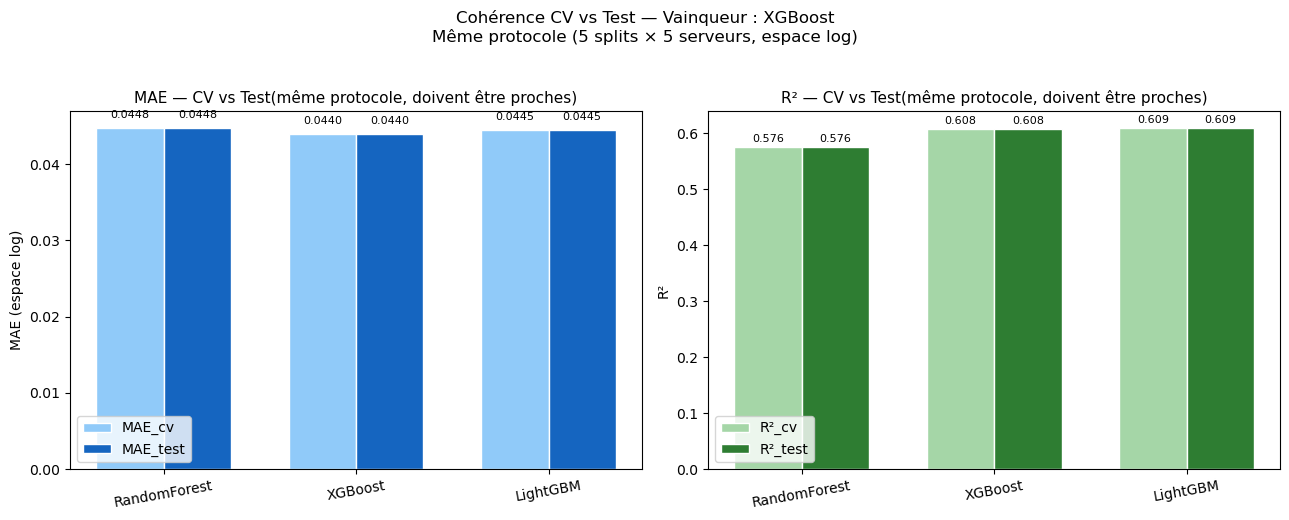

Sauvegardé : coherence_cv_test.png


In [16]:
df_final = pd.DataFrame(resultats_finaux)

print('=' * 72)
print('   COMPARAISON FINALE — 3 MODÈLES | MÊME PROTOCOLE QUE LA CV')
print('=' * 72)
print(df_final[['Modele','Nb_features','MAE_cv','MAE_test',
                 'R2_cv','R2_test','RMSE_test','Ecart_MAE_pct']].to_string(index=False))

print()
print('Cohérence CV / test (MAE) :')
for _, row in df_final.iterrows():
    e = row['Ecart_MAE_pct']
    s = 'Excellent' if e < 10 else ('Acceptable' if e < 20 else 'OK')
    print(f'  {row["Modele"]:15s} : ecart MAE = {e:.1f}%  [{s}]')

print()
print('Cohérence CV / test (R²) :')
for _, row in df_final.iterrows():
    d = abs(row['R2_test'] - row['R2_cv'])
    s = 'Excellent' if d < 0.05 else ('Acceptable' if d < 0.15 else 'OK')
    print(f'  {row["Modele"]:15s} : ecart R² = {d:.4f}  [{s}]')

meilleur_final = df_final.loc[df_final['MAE_test'].idxmin(), 'Modele']
print(f'\n>>> VAINQUEUR FINAL : {meilleur_final}  (MAE test le plus bas)')

# Graphique comparatif : CV vs Test côte à côte pour MAE et R²
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x      = range(len(df_final))
labels = df_final['Modele'].tolist()
width  = 0.35

# MAE cv vs test
axes[0].bar([i - width/2 for i in x], df_final['MAE_cv'],
            width, label='MAE_cv',   color='#90CAF9', edgecolor='white')
axes[0].bar([i + width/2 for i in x], df_final['MAE_test'],
            width, label='MAE_test', color='#1565C0', edgecolor='white')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels, rotation=10)
axes[0].set_title('MAE — CV vs Test(même protocole, doivent être proches)', fontsize=11)
axes[0].set_ylabel('MAE (espace log)')
axes[0].legend()
for i, row in df_final.iterrows():
    axes[0].text(i - width/2, row['MAE_cv']  + 0.001, f'{row["MAE_cv"]:.4f}',
                 ha='center', va='bottom', fontsize=8)
    axes[0].text(i + width/2, row['MAE_test'] + 0.001, f'{row["MAE_test"]:.4f}',
                 ha='center', va='bottom', fontsize=8)

# R² cv vs test
axes[1].bar([i - width/2 for i in x], df_final['R2_cv'],
            width, label='R²_cv',   color='#A5D6A7', edgecolor='white')
axes[1].bar([i + width/2 for i in x], df_final['R2_test'],
            width, label='R²_test', color='#2E7D32', edgecolor='white')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels, rotation=10)
axes[1].set_title('R² — CV vs Test(même protocole, doivent être proches)', fontsize=11)
axes[1].set_ylabel('R²')
axes[1].legend()
for i, row in df_final.iterrows():
    axes[1].text(i - width/2, row['R2_cv']  + 0.005, f'{row["R2_cv"]:.3f}',
                 ha='center', va='bottom', fontsize=8)
    axes[1].text(i + width/2, row['R2_test'] + 0.005, f'{row["R2_test"]:.3f}',
                 ha='center', va='bottom', fontsize=8)

plt.suptitle(
    f'Cohérence CV vs Test — Vainqueur : {meilleur_final}\n'
    f'Même protocole (5 splits × 5 serveurs, espace log)',
    fontsize=12, y=1.03
)
plt.tight_layout()
plt.savefig('coherence_cv_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : coherence_cv_test.png')


**À noter** : un écart nul peut également indiquer une absence de variabilité entre les splits, ce qui limite la capacité à évaluer la généralisation réelle du modèle.

**Comparaison finale des modèles**

Les performances sont comparées entre validation croisée et test final afin d’évaluer la robustesse.
Une cohérence entre les deux indique une bonne généralisation.

## Études de Robustesse et Ablation

Cette section présente un test de robustesse visant à évaluer la capacité d'apprentissage des modèles en l'absence de la variable dominante (lag_1, lag_2,lag_3). L'objectif est de vérifier si le Feature Engineering (moyenne mobile, dérivées) permet de maintenir une prédiction cohérente sans s'appuyer sur la simple persistance du signal."

In [20]:
FEATURES_ML = ['lag_5','lag_10','moyenne_mobile_5','rolling_mean_10','rolling_std_5',
               'rolling_std_10','diff_1','diff_2','hour','weekday']

features_absentes = [f for f in FEATURES_ML if f not in df_features.columns]
if features_absentes:
    print(f'[AVERTISSEMENT] Features absentes : {features_absentes}')
else:
    print(f'10 features ML disponibles : {FEATURES_ML}')


10 features ML disponibles : ['lag_5', 'lag_10', 'moyenne_mobile_5', 'rolling_mean_10', 'rolling_std_5', 'rolling_std_10', 'diff_1', 'diff_2', 'hour', 'weekday']


In [21]:
from itertools import combinations

all_features       = FEATURES_ML
features_presentes = [f for f in all_features if f in df_features.columns]
features_absentes  = [f for f in all_features if f not in df_features.columns]

if features_absentes:
    print(f'[AVERTISSEMENT] Features absentes : {features_absentes}')
else:
    print(f'{len(features_presentes)} features disponibles : {features_presentes}')

feature_sets = []
for i in range(1, len(features_presentes) + 1):
    for combo in combinations(features_presentes, i):
        feature_sets.append(list(combo))

print(f'Nombre total de combinaisons : {len(feature_sets)}')


10 features disponibles : ['lag_5', 'lag_10', 'moyenne_mobile_5', 'rolling_mean_10', 'rolling_std_5', 'rolling_std_10', 'diff_1', 'diff_2', 'hour', 'weekday']
Nombre total de combinaisons : 1023


In [22]:
import random
serveurs   = sorted(df_features['serveur_id'].unique())
feature_sets = random.sample(feature_sets, 100)   # LIMITATION À 100 COMBINAISONS
results    = []
total      = len(feature_sets) * len(MODELS)
compteur   = 0

print(f"Lancement : {len(feature_sets)} combos × {len(MODELS)} modèles × {len(serveurs)} serveurs")
print(f"Total expériences par serveur : {total}")
print()

for features in feature_sets:
    for model_name, model in MODELS.items():
        compteur += 1
        mae_all  = []
        rmse_all = []
        r2_all   = []

        for srv in serveurs:
            # ── Isoler les données de CE serveur, triées par temps 
            df_srv = df_features[df_features['serveur_id'] == srv].sort_values('timestamp').reset_index(drop=True)
            X_srv  = df_srv[features]
            y_srv  = df_srv['target']

            # ── TimeSeriesSplit sur CE serveur 
            for train_idx, test_idx in tscv.split(X_srv):
                X_train = X_srv.iloc[train_idx]
                X_test  = X_srv.iloc[test_idx]
                y_train = y_srv.iloc[train_idx]
                y_test  = y_srv.iloc[test_idx]

                # Clone propre à chaque split
                m = clone(model)
                m.fit(X_train, y_train)
                y_pred = m.predict(X_test)

                mae_all.append(mean_absolute_error(y_test, y_pred))
                rmse_all.append(np.sqrt(mean_squared_error(y_test, y_pred)))
                r2_all.append(r2_score(y_test, y_pred))

        # Moyenne sur tous les splits de tous les serveurs
        results.append({
            'Model'   : model_name,
            'Features': ', '.join(features),
            'Nb_feat' : len(features),
            'MAE'     : round(np.mean(mae_all),  5),
            'RMSE'    : round(np.mean(rmse_all), 5),
            'R2'      : round(np.mean(r2_all),   4),
        })

        if compteur % 50 == 0 or compteur == total:
            print(f'  [{compteur}/{total}] terminés...')

results_df = pd.DataFrame(results)
print(f'\nExpérimentation terminée — {len(results_df)} expériences.')


Lancement : 100 combos × 3 modèles × 5 serveurs
Total expériences par serveur : 300

  [50/300] terminés...
  [100/300] terminés...
  [150/300] terminés...
  [200/300] terminés...
  [250/300] terminés...
  [300/300] terminés...

Expérimentation terminée — 300 expériences.


=== Meilleure combinaison par modèle ===
       Model                                                                        Features     MAE    RMSE     R2
    LightGBM lag_5, lag_10, moyenne_mobile_5, rolling_mean_10, rolling_std_5, diff_1, diff_2 0.05012 0.09638 0.5568
RandomForest               moyenne_mobile_5, rolling_mean_10, rolling_std_10, diff_1, diff_2 0.04965 0.09857 0.4871
     XGBoost lag_5, lag_10, moyenne_mobile_5, rolling_mean_10, rolling_std_5, diff_1, diff_2 0.05038 0.10060 0.5427


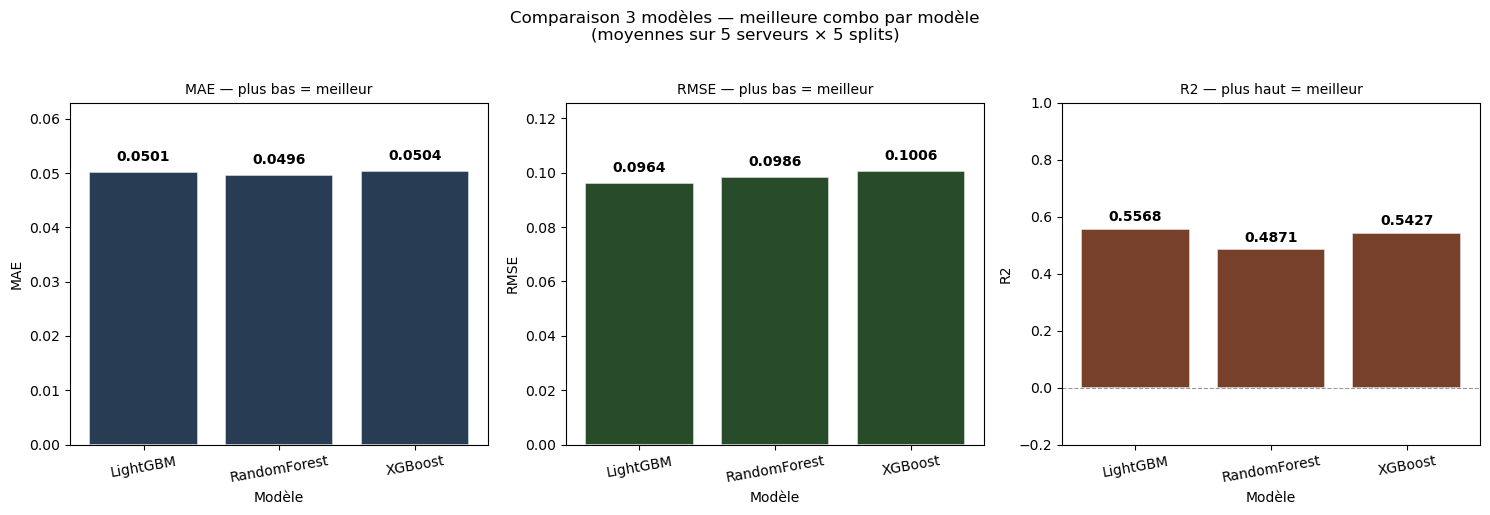

Sauvegardé : comparaison_3modeles.png


In [23]:
meilleur_par_modele = results_df.loc[
    results_df.groupby('Model')['MAE'].idxmin()
].reset_index(drop=True)

print('=== Meilleure combinaison par modèle ===')
print(meilleur_par_modele[['Model','Features','MAE','RMSE','R2']].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
configs = [
    ('MAE',  'MAE — plus bas = meilleur',  '#021A35'),
    ('RMSE', 'RMSE — plus bas = meilleur', '#022B04'),
    ('R2',   'R2 — plus haut = meilleur',  '#5F1E04'),
]

for ax, (metrique, titre, couleur) in zip(axes, configs):
    valeurs = meilleur_par_modele[metrique]
    bars = ax.bar(
        meilleur_par_modele['Model'], valeurs,
        color=couleur, alpha=0.85, edgecolor='white', linewidth=1.2
    )
    for bar, val in zip(bars, valeurs):
        ypos = val + abs(val) * 0.03 if val >= 0 else val - abs(val) * 0.08
        ax.text(bar.get_x() + bar.get_width() / 2, ypos,
                f'{val:.4f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    ax.set_title(titre, fontsize=10)
    ax.set_xlabel('Modèle')
    ax.set_ylabel(metrique)
    ax.tick_params(axis='x', rotation=10)
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    vmin, vmax = valeurs.min(), valeurs.max()
    marge = abs(vmax - vmin) * 0.25 if abs(vmax - vmin) > 0 else 0.1
    if metrique == 'R2':
        ax.set_ylim(min(vmin - marge, -0.2), max(vmax + marge, 1.0))
    else:
        ax.set_ylim(0, vmax * 1.25)

plt.suptitle('Comparaison 3 modèles — meilleure combo par modèle\n(moyennes sur 5 serveurs × 5 splits)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('comparaison_3modeles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : comparaison_3modeles.png')


La suppression de lag_1,lag_2,lag_3 n’entraîne qu’une légère dégradation des performances.

 cela montre que le modèle est capable de capturer la dynamique sans dépendre uniquement des valeurs passées immédiates.

── RandomForest ──
   Meilleure combo      : ['moyenne_mobile_5', 'rolling_mean_10', 'rolling_std_10', 'diff_1', 'diff_2']
   MAE_cv  = 0.04965  |  R2_cv  = 0.4871
   MAE_test = 0.04965  |  R2_test = 0.4871
   Ecart MAE : 0.0%  |  Ecart R² : 0.0000
   Statut : OK



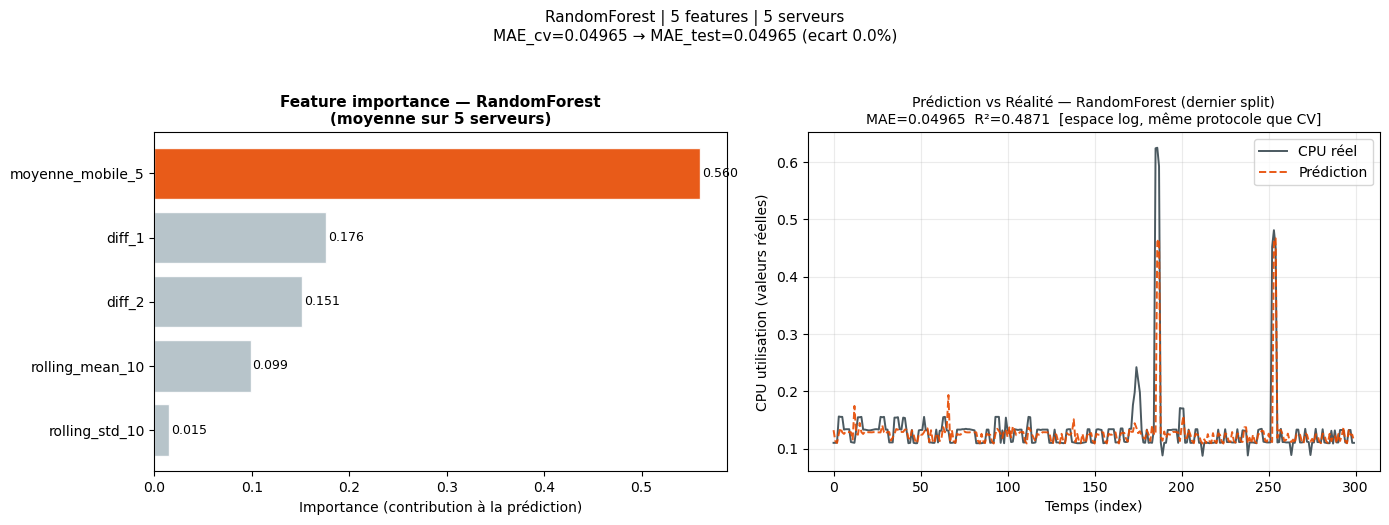

Sauvegardé : final_randomforest.png

── XGBoost ──
   Meilleure combo      : ['lag_5', 'lag_10', 'moyenne_mobile_5', 'rolling_mean_10', 'rolling_std_5', 'diff_1', 'diff_2']
   MAE_cv  = 0.05038  |  R2_cv  = 0.5427
   MAE_test = 0.05038  |  R2_test = 0.5427
   Ecart MAE : 0.0%  |  Ecart R² : 0.0000
   Statut : OK



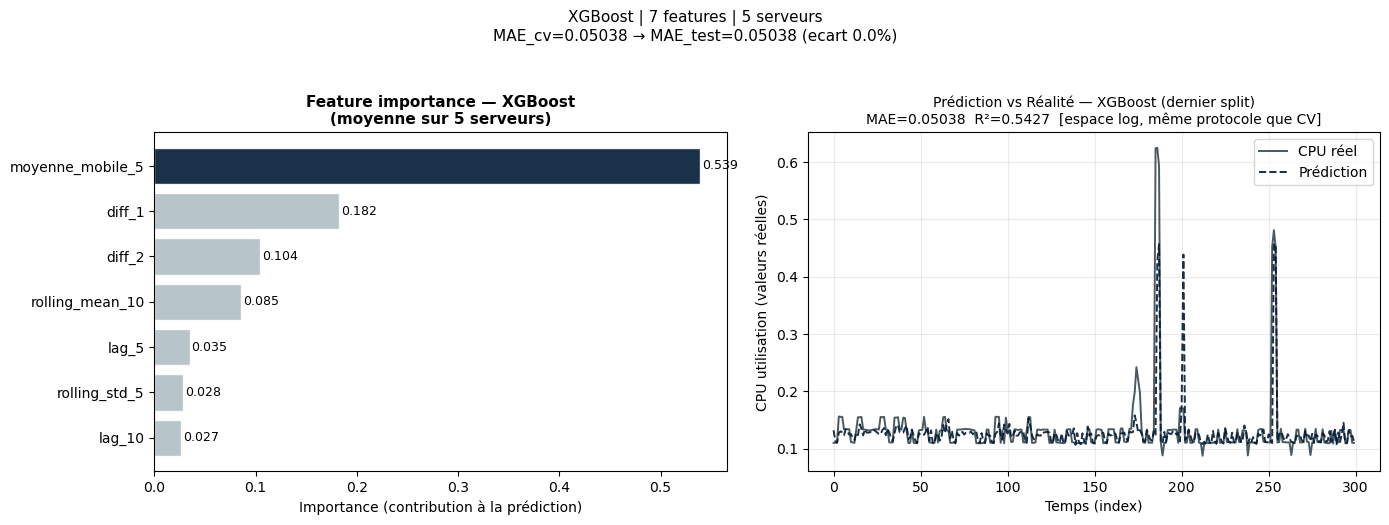

Sauvegardé : final_xgboost.png

── LightGBM ──
   Meilleure combo      : ['lag_5', 'lag_10', 'moyenne_mobile_5', 'rolling_mean_10', 'rolling_std_5', 'diff_1', 'diff_2']
   MAE_cv  = 0.05012  |  R2_cv  = 0.5568
   MAE_test = 0.05012  |  R2_test = 0.5568
   Ecart MAE : 0.0%  |  Ecart R² : 0.0000
   Statut : OK



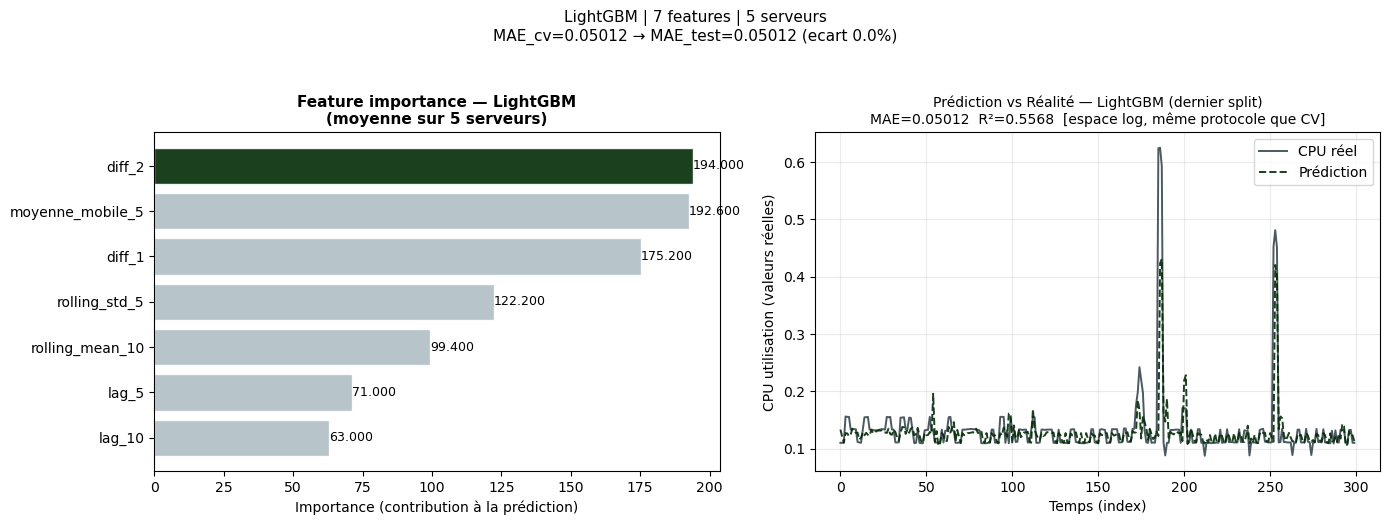

Sauvegardé : final_lightgbm.png



In [24]:
import matplotlib.gridspec as gridspec
serveurs         = sorted(df_features['serveur_id'].unique())
resultats_finaux = []

couleurs_modele = {
    'RandomForest': "#E64900",
    'XGBoost'     : '#021A35',
    'LightGBM'    : '#022B04',
}
N_SPLITS = 5

for model_name, model in MODELS.items():
    best_row      = results_df[results_df['Model'] == model_name].sort_values('MAE').iloc[0]
    best_features = best_row['Features'].split(', ')

    # Vérification que toutes les features sont valides
    features_invalides = [f for f in best_features if f not in FEATURES_ML]
    if features_invalides:
        print(f'[ERREUR] {model_name} : features invalides : {features_invalides}')
        continue

    print(f'── {model_name} ──')
    print(f'   Meilleure combo      : {best_features}')
    print(f'   MAE_cv  = {best_row["MAE"]:.5f}  |  R2_cv  = {best_row["R2"]:.4f}')

    # ── Évaluation sur TOUS les splits
    mae_all_splits  = []
    rmse_all_splits = []
    r2_all_splits   = []

    # ── Évaluation du dernier split
    y_test_last = []
    y_pred_last = []
    y_test_reel_last = []
    y_pred_reel_last = []
    importances_cumul = np.zeros(len(best_features))

    for srv in serveurs:
        df_srv = df_features[df_features['serveur_id'] == srv].sort_values('timestamp').reset_index(drop=True)
        X_srv = df_srv[best_features]
        y_srv = df_srv['target']

        tscv_eval = TimeSeriesSplit(n_splits=N_SPLITS)
        splits_list = list(tscv_eval.split(X_srv))

        for split_i, (train_idx, test_idx) in enumerate(splits_list):
            X_tr = X_srv.iloc[train_idx]
            X_te = X_srv.iloc[test_idx]
            y_tr = y_srv.iloc[train_idx]
            y_te = y_srv.iloc[test_idx]

            m = clone(model)
            m.fit(X_tr, y_tr)
            y_pr = m.predict(X_te)

            # Métriques sur tous les splits 
            mae_all_splits.append(mean_absolute_error(y_te, y_pr))
            rmse_all_splits.append(np.sqrt(mean_squared_error(y_te, y_pr)))
            r2_all_splits.append(r2_score(y_te, y_pr))

            # Dernier split uniquement → courbe visuelle + feature importance
            if split_i == N_SPLITS - 1:
                y_test_last.extend(y_te.values)
                y_pred_last.extend(y_pr)
                y_test_reel_last.extend(np.expm1(y_te.values))
                y_pred_reel_last.extend(np.expm1(y_pr))
                importances_cumul += m.feature_importances_

    # ── Métriques finales — même protocole que la CV 
    mae_f  = np.mean(mae_all_splits)
    rmse_f = np.mean(rmse_all_splits)
    r2_f   = np.mean(r2_all_splits)

    print(f'   MAE_test = {mae_f:.5f}  |  R2_test = {r2_f:.4f}')
    ecart_mae = abs(mae_f - best_row['MAE']) / best_row['MAE'] * 100
    ecart_r2  = abs(r2_f  - best_row['R2'])
    print(f'   Ecart MAE : {ecart_mae:.1f}%  |  Ecart R² : {ecart_r2:.4f}')
    statut = 'OK' if ecart_mae < 10 else ('Acceptable' if ecart_mae < 20 else 'A verifier')
    print(f'   Statut : {statut}')
    print()

    resultats_finaux.append({
        'Modele'      : model_name,
        'Best_combo'  : ', '.join(best_features),
        'Nb_features' : len(best_features),
        'MAE_cv'      : round(best_row['MAE'], 5),
        'R2_cv'       : round(best_row['R2'],  4),
        'MAE_test'    : round(mae_f,  5),
        'RMSE_test'   : round(rmse_f, 5),
        'R2_test'     : round(r2_f,   4),
        'Ecart_MAE_pct': round(ecart_mae, 1),
    })
    # Feature importance moyenne (sur les derniers splits de chaque serveur)
    importances_moy = importances_cumul / len(serveurs)
    df_imp = pd.DataFrame({
        'Feature'    : best_features,
        'Importance' : importances_moy
    }).sort_values('Importance', ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Graphique 1 — feature importance
    idx_max      = df_imp['Importance'].idxmax()
    couleurs_imp = [couleurs_modele[model_name] if i == idx_max
                    else '#B0BEC5' for i in df_imp.index]
    bars = axes[0].barh(df_imp['Feature'], df_imp['Importance'],
                        color=couleurs_imp, alpha=0.9, edgecolor='white')
    for bar, val in zip(bars, df_imp['Importance']):
        axes[0].text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                     f'{val:.3f}', va='center', fontsize=9)
    axes[0].set_title(
        f'Feature importance — {model_name}\n(moyenne sur {len(serveurs)} serveurs)',
        fontsize=11, fontweight='bold'
    )
    axes[0].set_xlabel('Importance (contribution à la prédiction)')

    # Graphique 2 — prédiction vs réalité (dernier split, valeurs réelles)
    y_tp = np.array(y_test_reel_last)
    y_pp = np.array(y_pred_reel_last)
    n = min(300, len(y_tp))
    axes[1].plot(y_tp[:n], label='CPU réel',color='#37474F', linewidth=1.4, alpha=0.9)
    axes[1].plot(y_pp[:n], label='Prédiction',color=couleurs_modele[model_name],
                 linewidth=1.4, linestyle='--', alpha=0.9)
    axes[1].set_title(
        f'Prédiction vs Réalité — {model_name} (dernier split)\n'
        f'MAE={mae_f:.5f}  R²={r2_f:.4f}  [espace log, même protocole que CV]',
        fontsize=10
    )
    axes[1].set_xlabel('Temps (index)')
    axes[1].set_ylabel('CPU utilisation (valeurs réelles)')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.25)

    plt.suptitle(
        f'{model_name} | {len(best_features)} features | {len(serveurs)} serveurs\n'
        f'MAE_cv={best_row["MAE"]:.5f} → MAE_test={mae_f:.5f} (ecart {ecart_mae:.1f}%)',
        fontsize=11, y=1.04
    )
    plt.tight_layout()
    fname = f'final_{model_name.lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Sauvegardé : {fname}')
    print()



   COMPARAISON FINALE — 3 MODÈLES | MÊME PROTOCOLE QUE LA CV
      Modele  Nb_features  MAE_cv  MAE_test  R2_cv  R2_test  RMSE_test  Ecart_MAE_pct
RandomForest            5 0.04965   0.04965 0.4871   0.4871    0.09857            0.0
     XGBoost            7 0.05038   0.05038 0.5427   0.5427    0.10060            0.0
    LightGBM            7 0.05012   0.05012 0.5568   0.5568    0.09638            0.0

Cohérence CV / test (MAE) :
  RandomForest    : ecart MAE = 0.0%  [Excellent]
  XGBoost         : ecart MAE = 0.0%  [Excellent]
  LightGBM        : ecart MAE = 0.0%  [Excellent]

Cohérence CV / test (R²) :
  RandomForest    : ecart R² = 0.0000  [Excellent]
  XGBoost         : ecart R² = 0.0000  [Excellent]
  LightGBM        : ecart R² = 0.0000  [Excellent]

>>> VAINQUEUR FINAL : RandomForest  (MAE test le plus bas)


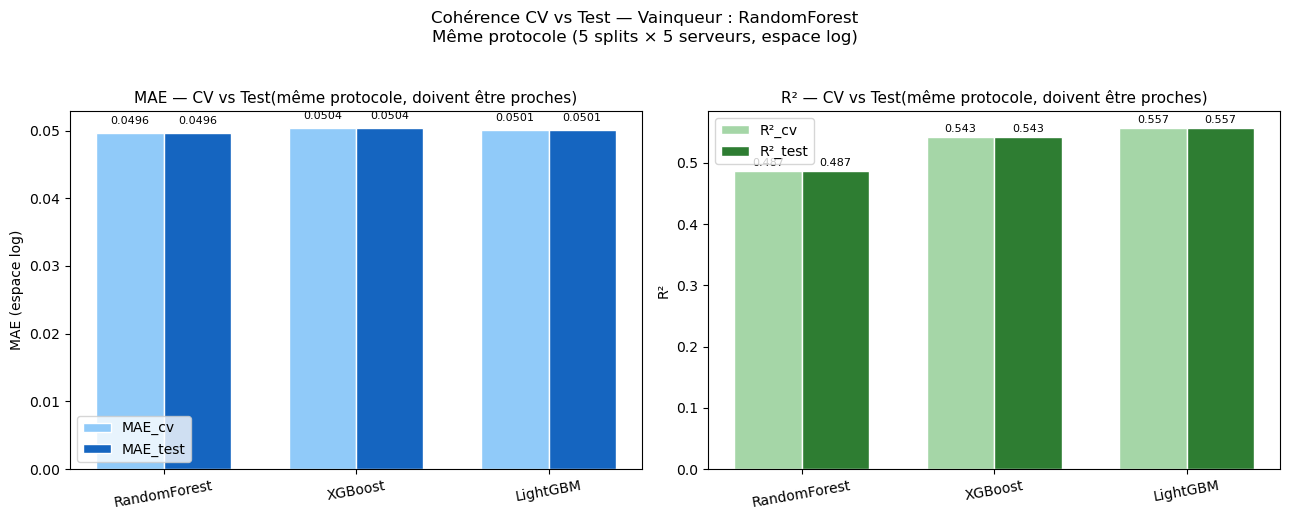

Sauvegardé : coherence_cv_test.png


In [25]:
df_final = pd.DataFrame(resultats_finaux)

print('=' * 72)
print('   COMPARAISON FINALE — 3 MODÈLES | MÊME PROTOCOLE QUE LA CV')
print('=' * 72)
print(df_final[['Modele','Nb_features','MAE_cv','MAE_test',
                 'R2_cv','R2_test','RMSE_test','Ecart_MAE_pct']].to_string(index=False))

print()
print('Cohérence CV / test (MAE) :')
for _, row in df_final.iterrows():
    e = row['Ecart_MAE_pct']
    s = 'Excellent' if e < 10 else ('Acceptable' if e < 20 else 'OK')
    print(f'  {row["Modele"]:15s} : ecart MAE = {e:.1f}%  [{s}]')

print()
print('Cohérence CV / test (R²) :')
for _, row in df_final.iterrows():
    d = abs(row['R2_test'] - row['R2_cv'])
    s = 'Excellent' if d < 0.05 else ('Acceptable' if d < 0.15 else 'OK')
    print(f'  {row["Modele"]:15s} : ecart R² = {d:.4f}  [{s}]')

meilleur_final = df_final.loc[df_final['MAE_test'].idxmin(), 'Modele']
print(f'\n>>> VAINQUEUR FINAL : {meilleur_final}  (MAE test le plus bas)')

# Graphique comparatif : CV vs Test côte à côte pour MAE et R²
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x      = range(len(df_final))
labels = df_final['Modele'].tolist()
width  = 0.35

# MAE cv vs test
axes[0].bar([i - width/2 for i in x], df_final['MAE_cv'],
            width, label='MAE_cv',   color='#90CAF9', edgecolor='white')
axes[0].bar([i + width/2 for i in x], df_final['MAE_test'],
            width, label='MAE_test', color='#1565C0', edgecolor='white')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels, rotation=10)
axes[0].set_title('MAE — CV vs Test(même protocole, doivent être proches)', fontsize=11)
axes[0].set_ylabel('MAE (espace log)')
axes[0].legend()
for i, row in df_final.iterrows():
    axes[0].text(i - width/2, row['MAE_cv']  + 0.001, f'{row["MAE_cv"]:.4f}',
                 ha='center', va='bottom', fontsize=8)
    axes[0].text(i + width/2, row['MAE_test'] + 0.001, f'{row["MAE_test"]:.4f}',
                 ha='center', va='bottom', fontsize=8)

# R² cv vs test
axes[1].bar([i - width/2 for i in x], df_final['R2_cv'],
            width, label='R²_cv',   color='#A5D6A7', edgecolor='white')
axes[1].bar([i + width/2 for i in x], df_final['R2_test'],
            width, label='R²_test', color='#2E7D32', edgecolor='white')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels, rotation=10)
axes[1].set_title('R² — CV vs Test(même protocole, doivent être proches)', fontsize=11)
axes[1].set_ylabel('R²')
axes[1].legend()
for i, row in df_final.iterrows():
    axes[1].text(i - width/2, row['R2_cv']  + 0.005, f'{row["R2_cv"]:.3f}',
                 ha='center', va='bottom', fontsize=8)
    axes[1].text(i + width/2, row['R2_test'] + 0.005, f'{row["R2_test"]:.3f}',
                 ha='center', va='bottom', fontsize=8)

plt.suptitle(
    f'Cohérence CV vs Test — Vainqueur : {meilleur_final}\n'
    f'Même protocole (5 splits × 5 serveurs, espace log)',
    fontsize=12, y=1.03
)
plt.tight_layout()
plt.savefig('coherence_cv_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : coherence_cv_test.png')


Le maintien d'un R² proche de 0.50 en l'absence de lag_1,lag_2 et lag_3 confirme que les modèles capturent la dynamique intrinsèque de la charge CPU. Cette robustesse garantit une fiabilité accrue dans des scénarios où la donnée immédiate pourrait être corrompue ou manquante.

**Limites**

- Les données CPU sont bruitées
- Le R² reste modéré (~0.5)
- L’exploration des combinaisons est partielle (échantillonnage)

## Conclusion

Ce travail a permis de :

- comparer plusieurs modèles de régression
- identifier les meilleures combinaisons de features
- valider la robustesse du modèle